# Evaluation Comparison: Oracle vs Policy Trajectories

Compare two SWE-bench evaluation runs:
- **Oracle**: `oracle_traj_128k_swegym_resolved_632i_qwen2.5_coder_32b_full_128k_megatron_20260426_114247`
- **Policy**: `policy_traj_128k_swegym_resolved_634i_qwen2.5_coder_32b_full_128k_megatron_20260420_005928`

In [31]:
import json
import os
import re
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import numpy as np

def normalize_command(cmd):
    """Normalize a command string by collapsing whitespace for fingerprinting."""
    if not cmd:
        return ""
    return re.sub(r'\s+', ' ', cmd).strip()

def make_fingerprint(action, args):
    """Create a normalized fingerprint for an agent action."""
    if action == "run":
        cmd = normalize_command((args.get("command", "") or ""))[:100]
        return f"run:{cmd}"
    elif action == "edit":
        sub_cmd = (args.get("command", "") or "").strip()
        path = (args.get("path", "") or "").strip()
        return f"edit:{sub_cmd}:{path}"
    elif action == "read":
        path = (args.get("path", "") or "").strip()
        return f"read:{path}"
    else:
        return f"{action}"

BASE = "/home/v-murongma/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs_thin/princeton-nlp__SWE-bench_Verified-test/CodeActAgent"

ORACLE_DIR = os.path.join(BASE, "oracle_traj_128k_swegym_resolved_632i_qwen2.5_coder_32b_full_128k_megatron_20260426_114247_maxiter_100_N_v0.61.0-thin-no-hint")
POLICY_DIR = os.path.join(BASE, "policy_traj_128k_swegym_resolved_634i_qwen2.5_coder_32b_full_128k_megatron_20260420_005928_maxiter_100_N_v0.61.0-thin-no-hint")

LABELS = {"oracle": "Oracle", "policy": "Policy"}

## 1. Load Reports and Trajectories

In [32]:
def load_report(run_dir):
    with open(os.path.join(run_dir, "report.json")) as f:
        return json.load(f)

def load_trajectories(run_dir):
    """Load output.jsonl into a dict keyed by instance_id."""
    trajs = {}
    with open(os.path.join(run_dir, "output.jsonl")) as f:
        for line in f:
            entry = json.loads(line)
            trajs[entry["instance_id"]] = entry
    return trajs

oracle_report = load_report(ORACLE_DIR)
policy_report = load_report(POLICY_DIR)

print("Loading oracle trajectories...")
oracle_trajs = load_trajectories(ORACLE_DIR)
print(f"  Loaded {len(oracle_trajs)} instances")

print("Loading policy trajectories...")
policy_trajs = load_trajectories(POLICY_DIR)
print(f"  Loaded {len(policy_trajs)} instances")

Loading oracle trajectories...
  Loaded 496 instances
Loading policy trajectories...
  Loaded 497 instances


## 2. Resolved Instance Comparison (Venn Diagram)

In [33]:
oracle_resolved = set(oracle_report.get("resolved_ids", []))
policy_resolved = set(policy_report.get("resolved_ids", []))

both_resolved = oracle_resolved & policy_resolved
only_oracle = oracle_resolved - policy_resolved
only_policy = policy_resolved - oracle_resolved
neither = (set(oracle_trajs.keys()) | set(policy_trajs.keys())) - oracle_resolved - policy_resolved

print(f"Oracle resolved:      {len(oracle_resolved)}")
print(f"Policy resolved:      {len(policy_resolved)}")
print(f"Both resolved:        {len(both_resolved)}")
print(f"Only Oracle resolved: {len(only_oracle)}")
print(f"Only Policy resolved: {len(only_policy)}")
print(f"Neither resolved:     {len(neither)}")
print(f"\nUnion resolved:       {len(oracle_resolved | policy_resolved)}")

Oracle resolved:      111
Policy resolved:      213
Both resolved:        96
Only Oracle resolved: 15
Only Policy resolved: 117
Neither resolved:     270

Union resolved:       228


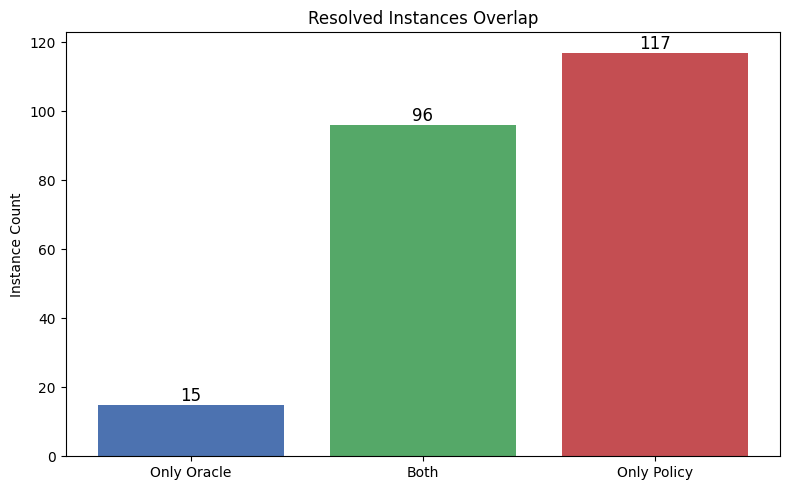

In [34]:
try:
    from matplotlib_venn import venn2
    fig, ax = plt.subplots(figsize=(8, 6))
    v = venn2(
        [oracle_resolved, policy_resolved],
        set_labels=("Oracle", "Policy"),
        ax=ax
    )
    ax.set_title("Resolved Instances Overlap")
    plt.tight_layout()
    plt.show()
except ImportError:
    # Fallback: bar chart
    fig, ax = plt.subplots(figsize=(8, 5))
    categories = ["Only Oracle", "Both", "Only Policy"]
    counts = [len(only_oracle), len(both_resolved), len(only_policy)]
    colors = ["#4C72B0", "#55A868", "#C44E52"]
    bars = ax.bar(categories, counts, color=colors)
    ax.bar_label(bars, fontsize=12)
    ax.set_ylabel("Instance Count")
    ax.set_title("Resolved Instances Overlap")
    plt.tight_layout()
    plt.show()

In [35]:
print("=== Only Oracle Resolved ===")
for iid in sorted(only_oracle):
    print(f"  {iid}")

print(f"\n=== Only Policy Resolved ===")
for iid in sorted(only_policy):
    print(f"  {iid}")

=== Only Oracle Resolved ===
  django__django-11333
  django__django-11451
  django__django-12193
  django__django-12774
  django__django-13417
  django__django-13568
  django__django-14493
  django__django-15278
  django__django-16100
  django__django-16485
  django__django-16661
  scikit-learn__scikit-learn-10908
  sympy__sympy-15349
  sympy__sympy-15875
  sympy__sympy-23824

=== Only Policy Resolved ===
  astropy__astropy-7166
  astropy__astropy-7336
  django__django-10880
  django__django-10914
  django__django-11211
  django__django-11292
  django__django-11299
  django__django-11551
  django__django-11603
  django__django-11749
  django__django-12143
  django__django-12209
  django__django-12276
  django__django-12713
  django__django-12858
  django__django-13028
  django__django-13279
  django__django-13343
  django__django-13363
  django__django-13401
  django__django-13410
  django__django-13516
  django__django-13551
  django__django-13569
  django__django-13590
  django__dja

## 3. Trajectory Analysis Helpers

In [36]:
def analyze_trajectory(entry, min_repeat=5):
    """Extract stats from a single trajectory entry."""
    history = entry.get("history", [])
    
    # Count actions (agent steps)
    actions = [e for e in history if "action" in e and e.get("source") == "agent"]
    observations = [e for e in history if "observation" in e]
    
    # Step count = number of agent actions
    step_count = len(actions)
    
    # Action type distribution
    action_types = Counter(a.get("action", "unknown") for a in actions)
    
    # Check for stuck-in-loop: error field OR fingerprint-based detection
    error = entry.get("error", "") or ""
    stuck_in_loop = "StuckInLoop" in error or "stuck in a loop" in error.lower()
    
    # Fingerprint-based loop detection (catches loops not flagged by error field)
    if not stuck_in_loop:
        fingerprints = []
        for a in actions:
            act = a.get("action", "")
            act_args = a.get("args", {}) if isinstance(a.get("args"), dict) else {}
            fingerprints.append(make_fingerprint(act, act_args))
        for i in range(len(fingerprints) - min_repeat + 1):
            window = fingerprints[i:i + min_repeat]
            if all(w == window[0] for w in window):
                stuck_in_loop = True
                break
    
    # Tool misuse: observations with success=False or error observations
    error_obs = [o for o in observations if o.get("observation") == "error" 
                 or o.get("success") == False]
    tool_misuse_count = len(error_obs)
    total_tool_uses = len(observations)
    
    # Cost and tokens
    metrics = entry.get("metrics", {})
    cost = metrics.get("accumulated_cost", 0)
    token_usage = metrics.get("accumulated_token_usage", {})
    
    return {
        "step_count": step_count,
        "action_types": dict(action_types),
        "stuck_in_loop": stuck_in_loop,
        "tool_misuse_count": tool_misuse_count,
        "total_tool_uses": total_tool_uses,
        "tool_misuse_rate": tool_misuse_count / total_tool_uses if total_tool_uses > 0 else 0,
        "cost": cost,
        "prompt_tokens": token_usage.get("prompt_tokens", 0),
        "completion_tokens": token_usage.get("completion_tokens", 0),
        "error": error,
    }

def analyze_all(trajs):
    return {iid: analyze_trajectory(entry) for iid, entry in trajs.items()}

print("Analyzing oracle trajectories...")
oracle_stats = analyze_all(oracle_trajs)
print("Analyzing policy trajectories...")
policy_stats = analyze_all(policy_trajs)
print("Done.")

Analyzing oracle trajectories...
Analyzing policy trajectories...
Done.


## 4. Step Length Statistics

In [37]:
# Common instances for fair comparison
common_ids = set(oracle_stats.keys()) & set(policy_stats.keys())
print(f"Common instances: {len(common_ids)}")

oracle_steps = [oracle_stats[iid]["step_count"] for iid in common_ids]
policy_steps = [policy_stats[iid]["step_count"] for iid in common_ids]

def print_step_stats(name, steps):
    arr = np.array(steps)
    print(f"{name}:")
    print(f"  Mean: {arr.mean():.1f}, Median: {np.median(arr):.1f}, "
          f"Std: {arr.std():.1f}, Min: {arr.min()}, Max: {arr.max()}")

print_step_stats("Oracle", oracle_steps)
print_step_stats("Policy", policy_steps)

Common instances: 495
Oracle:
  Mean: 82.0, Median: 88.0, Std: 20.6, Min: 21, Max: 101
Policy:
  Mean: 86.1, Median: 94.0, Std: 17.6, Min: 34, Max: 101


/tmp/ipykernel_1107513/2415785993.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([oracle_steps, policy_steps], labels=["Oracle", "Policy"], patch_artist=True)


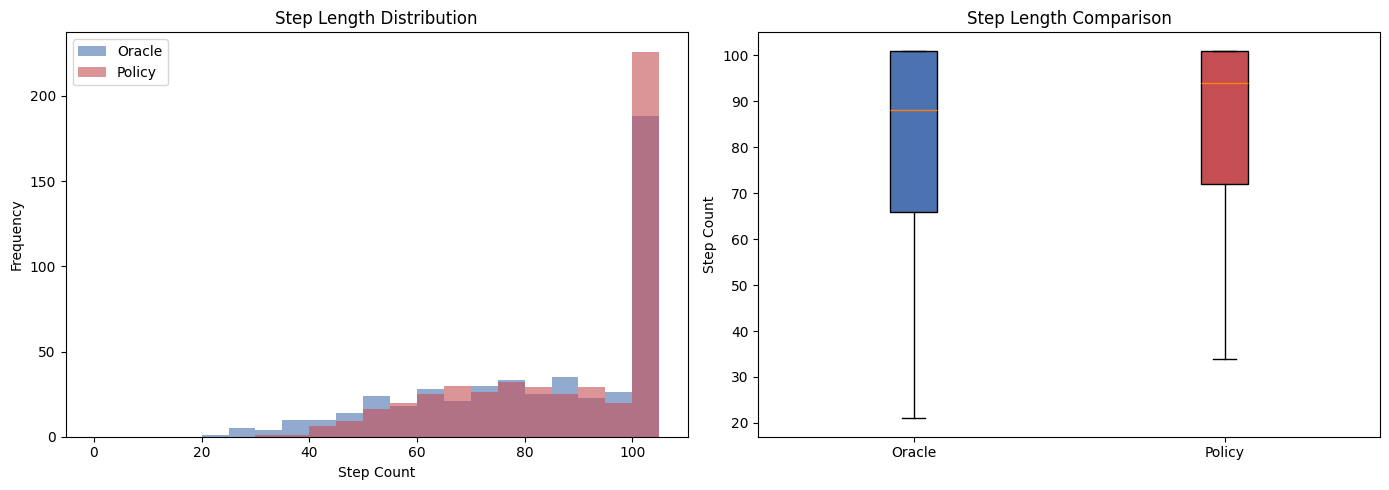

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
bins = np.arange(0, max(max(oracle_steps), max(policy_steps)) + 5, 5)
ax.hist(oracle_steps, bins=bins, alpha=0.6, label="Oracle", color="#4C72B0")
ax.hist(policy_steps, bins=bins, alpha=0.6, label="Policy", color="#C44E52")
ax.set_xlabel("Step Count")
ax.set_ylabel("Frequency")
ax.set_title("Step Length Distribution")
ax.legend()

# Box plot
ax = axes[1]
bp = ax.boxplot([oracle_steps, policy_steps], labels=["Oracle", "Policy"], patch_artist=True)
bp["boxes"][0].set_facecolor("#4C72B0")
bp["boxes"][1].set_facecolor("#C44E52")
ax.set_ylabel("Step Count")
ax.set_title("Step Length Comparison")

plt.tight_layout()
plt.show()

/tmp/ipykernel_1107513/1548926576.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


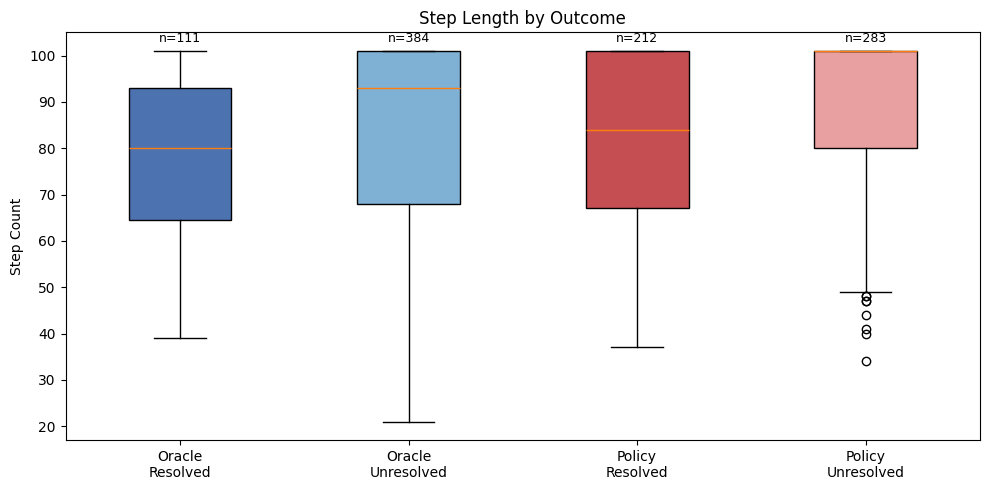

In [39]:
# Step length by outcome (resolved vs unresolved)
def steps_by_outcome(stats, resolved_set, ids):
    resolved_steps = [stats[i]["step_count"] for i in ids if i in resolved_set]
    unresolved_steps = [stats[i]["step_count"] for i in ids if i not in resolved_set]
    return resolved_steps, unresolved_steps

o_res, o_unres = steps_by_outcome(oracle_stats, oracle_resolved, common_ids)
p_res, p_unres = steps_by_outcome(policy_stats, policy_resolved, common_ids)

fig, ax = plt.subplots(figsize=(10, 5))
data = [o_res, o_unres, p_res, p_unres]
labels = ["Oracle\nResolved", "Oracle\nUnresolved", "Policy\nResolved", "Policy\nUnresolved"]
colors = ["#4C72B0", "#7EB1D4", "#C44E52", "#E8A0A0"]
bp = ax.boxplot(data, labels=labels, patch_artist=True)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
ax.set_ylabel("Step Count")
ax.set_title("Step Length by Outcome")
for i, d in enumerate(data):
    ax.text(i + 1, max(d) + 2 if d else 0, f"n={len(d)}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## 5. Tool Use Types

In [10]:
def aggregate_action_types(stats):
    total = Counter()
    for iid, s in stats.items():
        total.update(s["action_types"])
    return total

oracle_actions = aggregate_action_types(oracle_stats)
policy_actions = aggregate_action_types(policy_stats)

all_types = sorted(set(oracle_actions.keys()) | set(policy_actions.keys()))

print(f"{'Action Type':<20} {'Oracle':>10} {'Policy':>10} {'Oracle %':>10} {'Policy %':>10}")
print("-" * 62)
oracle_total = sum(oracle_actions.values())
policy_total = sum(policy_actions.values())
for t in all_types:
    oc = oracle_actions.get(t, 0)
    pc = policy_actions.get(t, 0)
    print(f"{t:<20} {oc:>10} {pc:>10} {100*oc/oracle_total:>9.1f}% {100*pc/policy_total:>9.1f}%")
print("-" * 62)
print(f"{'TOTAL':<20} {oracle_total:>10} {policy_total:>10}")

Action Type              Oracle     Policy   Oracle %   Policy %
--------------------------------------------------------------
condensation_request         40          1       0.1%       0.0%
edit                       6251       8423      15.4%      19.7%
finish                      194        267       0.5%       0.6%
message                      30         37       0.1%       0.1%
read                      12026      10312      29.6%      24.1%
run                       19719      22387      48.5%      52.3%
system                      496        497       1.2%       1.2%
task_tracking                 5         16       0.0%       0.0%
think                      1919        841       4.7%       2.0%
--------------------------------------------------------------
TOTAL                     40680      42781


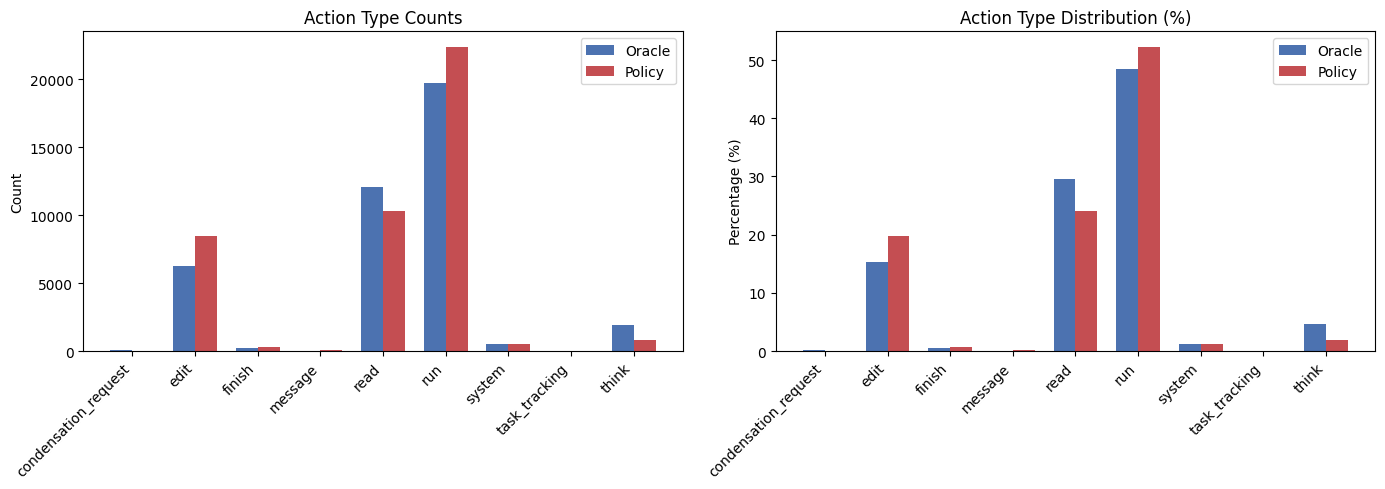

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar chart
ax = axes[0]
x = np.arange(len(all_types))
width = 0.35
o_vals = [oracle_actions.get(t, 0) for t in all_types]
p_vals = [policy_actions.get(t, 0) for t in all_types]
ax.bar(x - width/2, o_vals, width, label="Oracle", color="#4C72B0")
ax.bar(x + width/2, p_vals, width, label="Policy", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(all_types, rotation=45, ha="right")
ax.set_ylabel("Count")
ax.set_title("Action Type Counts")
ax.legend()

# Normalized bar chart (proportions)
ax = axes[1]
o_pct = [100 * oracle_actions.get(t, 0) / oracle_total for t in all_types]
p_pct = [100 * policy_actions.get(t, 0) / policy_total for t in all_types]
ax.bar(x - width/2, o_pct, width, label="Oracle", color="#4C72B0")
ax.bar(x + width/2, p_pct, width, label="Policy", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(all_types, rotation=45, ha="right")
ax.set_ylabel("Percentage (%)")
ax.set_title("Action Type Distribution (%)")
ax.legend()

plt.tight_layout()
plt.show()

## 6. Tool Misuse Analysis

In [12]:
def misuse_summary(stats, label):
    misuse_rates = [s["tool_misuse_rate"] for s in stats.values()]
    misuse_counts = [s["tool_misuse_count"] for s in stats.values()]
    total_uses = [s["total_tool_uses"] for s in stats.values()]
    total_misuse = sum(misuse_counts)
    total_use = sum(total_uses)
    print(f"{label}:")
    print(f"  Total tool uses:    {total_use}")
    print(f"  Total misuses:      {total_misuse}")
    print(f"  Overall misuse rate: {100*total_misuse/total_use:.1f}%")
    arr = np.array(misuse_rates)
    print(f"  Per-instance misuse rate: mean={100*arr.mean():.1f}%, "
          f"median={100*np.median(arr):.1f}%, max={100*arr.max():.1f}%")
    instances_with_misuse = sum(1 for r in misuse_rates if r > 0)
    print(f"  Instances with any misuse: {instances_with_misuse}/{len(misuse_rates)} "
          f"({100*instances_with_misuse/len(misuse_rates):.1f}%)")

misuse_summary(oracle_stats, "Oracle")
print()
misuse_summary(policy_stats, "Policy")

Oracle:
  Total tool uses:    40518
  Total misuses:      7181
  Overall misuse rate: 17.7%
  Per-instance misuse rate: mean=17.5%, median=16.1%, max=81.7%
  Instances with any misuse: 489/496 (98.6%)

Policy:
  Total tool uses:    42658
  Total misuses:      7190
  Overall misuse rate: 16.9%
  Per-instance misuse rate: mean=16.4%, median=15.5%, max=68.0%
  Instances with any misuse: 495/497 (99.6%)


/tmp/ipykernel_1107513/2804741045.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


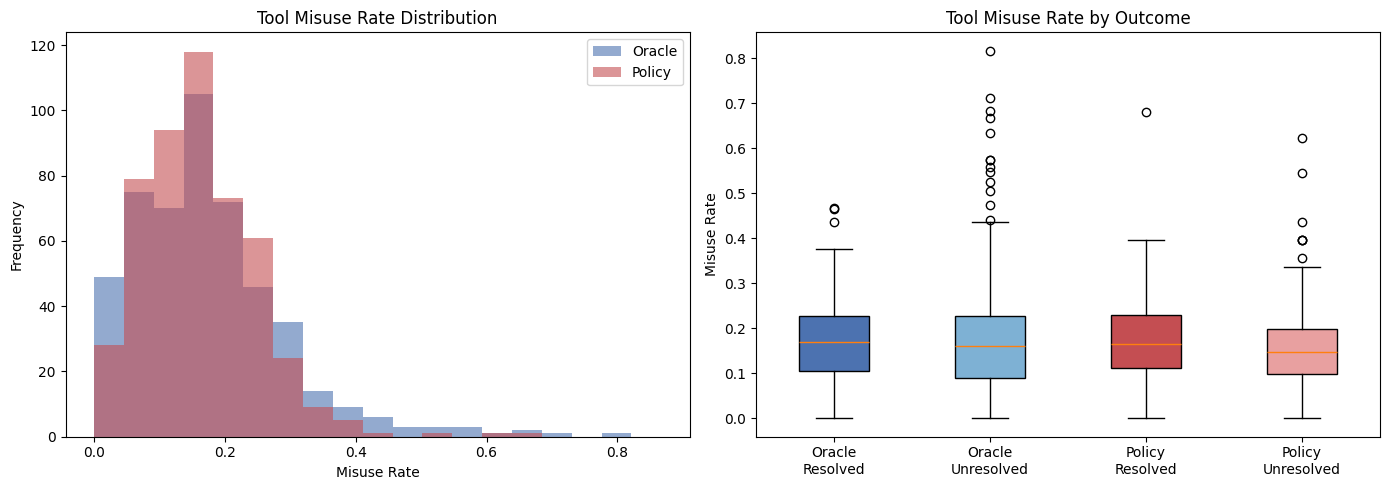

In [13]:
# Misuse rate distribution
oracle_misuse = [oracle_stats[i]["tool_misuse_rate"] for i in common_ids]
policy_misuse = [policy_stats[i]["tool_misuse_rate"] for i in common_ids]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bins = np.linspace(0, max(max(oracle_misuse), max(policy_misuse)) + 0.05, 20)
ax.hist(oracle_misuse, bins=bins, alpha=0.6, label="Oracle", color="#4C72B0")
ax.hist(policy_misuse, bins=bins, alpha=0.6, label="Policy", color="#C44E52")
ax.set_xlabel("Misuse Rate")
ax.set_ylabel("Frequency")
ax.set_title("Tool Misuse Rate Distribution")
ax.legend()

# Misuse rate: resolved vs unresolved
ax = axes[1]
o_res_m = [oracle_stats[i]["tool_misuse_rate"] for i in common_ids if i in oracle_resolved]
o_unres_m = [oracle_stats[i]["tool_misuse_rate"] for i in common_ids if i not in oracle_resolved]
p_res_m = [policy_stats[i]["tool_misuse_rate"] for i in common_ids if i in policy_resolved]
p_unres_m = [policy_stats[i]["tool_misuse_rate"] for i in common_ids if i not in policy_resolved]

data = [o_res_m, o_unres_m, p_res_m, p_unres_m]
labels = ["Oracle\nResolved", "Oracle\nUnresolved", "Policy\nResolved", "Policy\nUnresolved"]
colors = ["#4C72B0", "#7EB1D4", "#C44E52", "#E8A0A0"]
bp = ax.boxplot(data, labels=labels, patch_artist=True)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
ax.set_ylabel("Misuse Rate")
ax.set_title("Tool Misuse Rate by Outcome")
plt.tight_layout()
plt.show()

## 7. Stuck in Loop Analysis

In [40]:
oracle_stuck = sum(1 for s in oracle_stats.values() if s["stuck_in_loop"])
policy_stuck = sum(1 for s in policy_stats.values() if s["stuck_in_loop"])

oracle_n = len(oracle_stats)
policy_n = len(policy_stats)

print(f"Oracle: {oracle_stuck}/{oracle_n} stuck in loop ({100*oracle_stuck/oracle_n:.1f}%)")
print(f"Policy: {policy_stuck}/{policy_n} stuck in loop ({100*policy_stuck/policy_n:.1f}%)")

# Stuck in loop AND resolved?
oracle_stuck_resolved = sum(1 for iid, s in oracle_stats.items() 
                            if s["stuck_in_loop"] and iid in oracle_resolved)
policy_stuck_resolved = sum(1 for iid, s in policy_stats.items() 
                            if s["stuck_in_loop"] and iid in policy_resolved)
print(f"\nOracle stuck but resolved: {oracle_stuck_resolved}")
print(f"Policy stuck but resolved: {policy_stuck_resolved}")

Oracle: 255/496 stuck in loop (51.4%)
Policy: 137/497 stuck in loop (27.6%)

Oracle stuck but resolved: 34
Policy stuck but resolved: 53


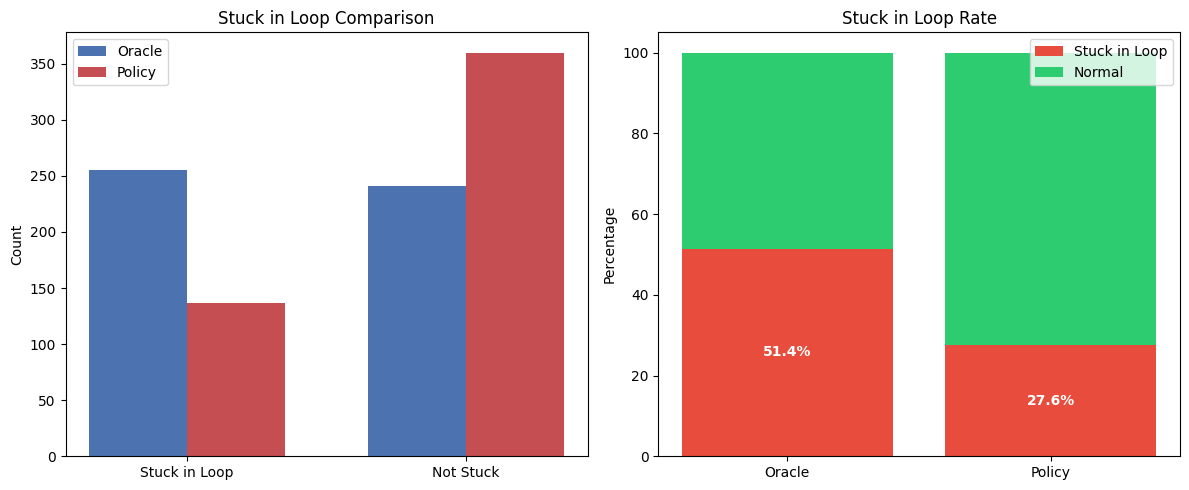

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart: stuck vs not stuck
ax = axes[0]
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, [oracle_stuck, oracle_n - oracle_stuck], width,
       label="Oracle", color="#4C72B0")
ax.bar(x + width/2, [policy_stuck, policy_n - policy_stuck], width,
       label="Policy", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(["Stuck in Loop", "Not Stuck"])
ax.set_ylabel("Count")
ax.set_title("Stuck in Loop Comparison")
ax.legend()

# Stacked bar: stuck rate as percentage
ax = axes[1]
runs = ["Oracle", "Policy"]
stuck_pct = [100*oracle_stuck/oracle_n, 100*policy_stuck/policy_n]
not_stuck_pct = [100 - s for s in stuck_pct]
ax.bar(runs, stuck_pct, label="Stuck in Loop", color="#E74C3C")
ax.bar(runs, not_stuck_pct, bottom=stuck_pct, label="Normal", color="#2ECC71")
for i, (s, ns) in enumerate(zip(stuck_pct, not_stuck_pct)):
    ax.text(i, s/2, f"{s:.1f}%", ha="center", va="center", fontweight="bold", color="white")
ax.set_ylabel("Percentage")
ax.set_title("Stuck in Loop Rate")
ax.legend()

plt.tight_layout()
plt.show()

### 7b. At Which Step Does the Stuck-in-Loop Occur?

Detect the step index where repetitive actions begin, to see whether stuck-in-loop correlates with trajectory length / inference budget.

In [42]:
def find_loop_start_step(entry, min_repeat=5):
    """Find the agent step index where the first stuck-in-loop pattern begins.
    
    Returns (loop_start_step, total_steps) or None if no loop detected.
    """
    history = entry.get("history", [])
    fingerprints = []
    for evt in history:
        if not isinstance(evt, dict):
            continue
        if evt.get("source") != "agent" or "action" not in evt:
            continue
        action = evt.get("action", "")
        args = evt.get("args", {}) if isinstance(evt.get("args"), dict) else {}
        fingerprints.append(make_fingerprint(action, args))
    total_steps = len(fingerprints)
    for i in range(len(fingerprints) - min_repeat + 1):
        window = fingerprints[i:i + min_repeat]
        if all(w == window[0] for w in window):
            return i, total_steps
    return None

# Scan ALL instances for loops (not just those flagged by error field)
oracle_loop_starts = {}
policy_loop_starts = {}
for iid, entry in oracle_trajs.items():
    result = find_loop_start_step(entry)
    if result:
        oracle_loop_starts[iid] = result
for iid, entry in policy_trajs.items():
    result = find_loop_start_step(entry)
    if result:
        policy_loop_starts[iid] = result

print(f"Oracle instances with detected loop: {len(oracle_loop_starts)}/{len(oracle_trajs)}")
print(f"Policy instances with detected loop: {len(policy_loop_starts)}/{len(policy_trajs)}")

Oracle instances with detected loop: 236/496
Policy instances with detected loop: 133/497


In [43]:
def print_loop_stats(name, loop_starts):
    if not loop_starts:
        print(f"{name}: No stuck-in-loop instances detected")
        return
    starts = [v[0] for v in loop_starts.values()]
    ratios = [s / t if t > 0 else 0 for s, t in loop_starts.values()]
    arr_s = np.array(starts)
    arr_r = np.array(ratios)
    print(f"{name} (n={len(starts)}):")
    print(f"  Loop start step  — Mean: {arr_s.mean():.1f}, Median: {np.median(arr_s):.0f}, "
          f"Min: {arr_s.min()}, Max: {arr_s.max()}")
    print(f"  Loop start ratio — Mean: {arr_r.mean():.2f}, Median: {np.median(arr_r):.2f}  "
          f"(start_step / total_steps)")

print_loop_stats("Oracle", oracle_loop_starts)
print()
print_loop_stats("Policy", policy_loop_starts)

Oracle (n=236):
  Loop start step  — Mean: 45.3, Median: 42, Min: 7, Max: 96
  Loop start ratio — Mean: 0.56, Median: 0.55  (start_step / total_steps)

Policy (n=133):
  Loop start step  — Mean: 47.6, Median: 44, Min: 8, Max: 96
  Loop start ratio — Mean: 0.52, Median: 0.51  (start_step / total_steps)


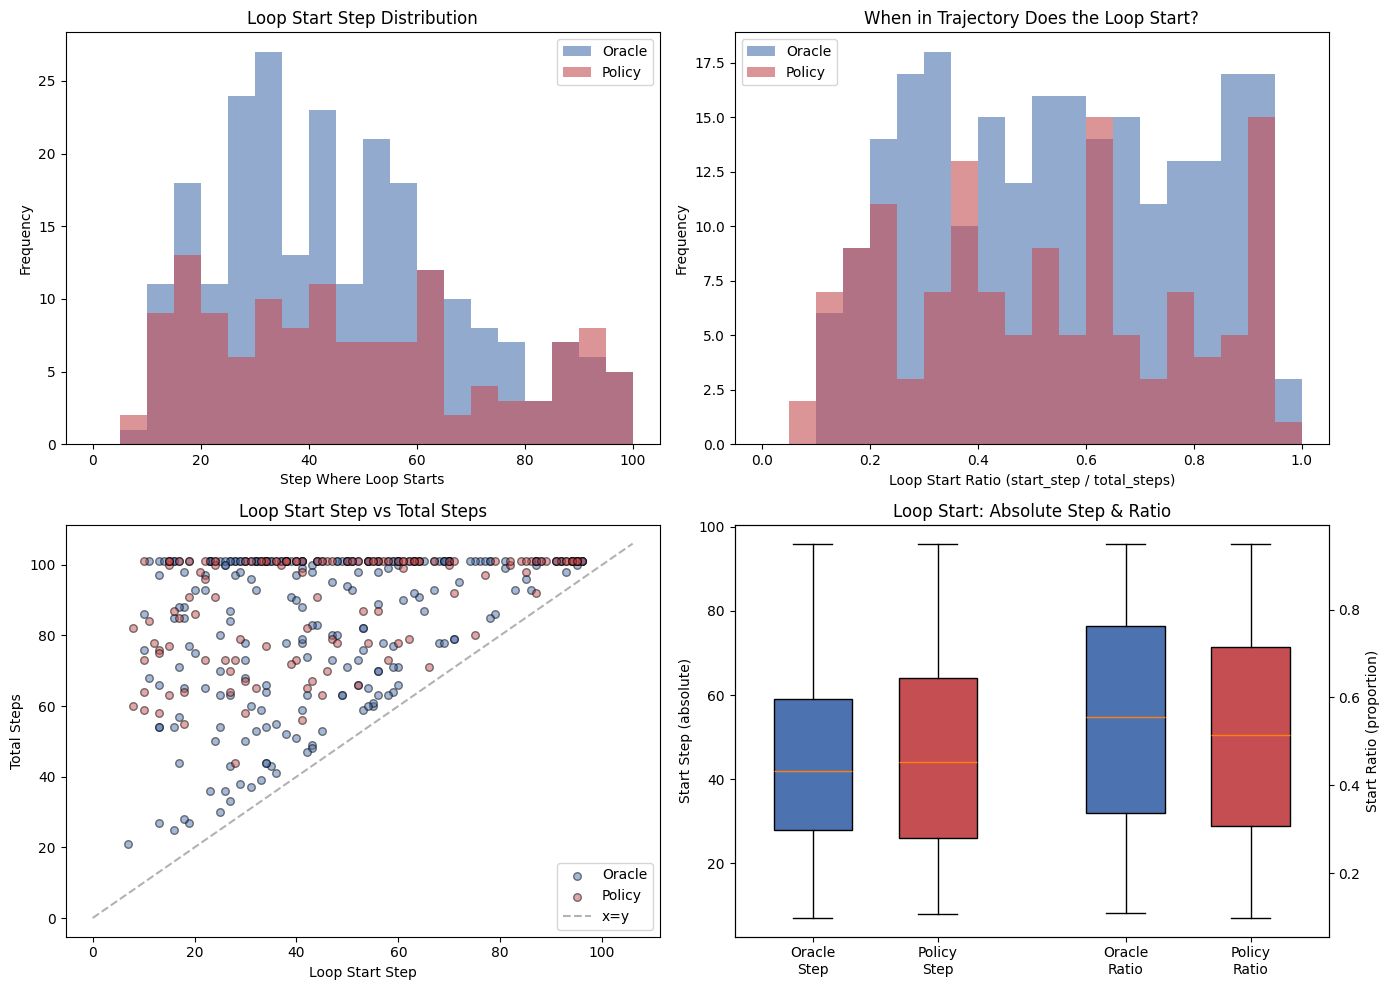

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

o_starts = [v[0] for v in oracle_loop_starts.values()]
p_starts = [v[0] for v in policy_loop_starts.values()]
o_ratios = [v[0] / v[1] if v[1] > 0 else 0 for v in oracle_loop_starts.values()]
p_ratios = [v[0] / v[1] if v[1] > 0 else 0 for v in policy_loop_starts.values()]

# 1. Histogram of absolute loop start step
ax = axes[0, 0]
max_step = max(max(o_starts, default=0), max(p_starts, default=0))
bins = np.arange(0, max_step + 5, 5)
ax.hist(o_starts, bins=bins, alpha=0.6, label="Oracle", color="#4C72B0")
ax.hist(p_starts, bins=bins, alpha=0.6, label="Policy", color="#C44E52")
ax.set_xlabel("Step Where Loop Starts")
ax.set_ylabel("Frequency")
ax.set_title("Loop Start Step Distribution")
ax.legend()

# 2. Histogram of loop start ratio (start_step / total_steps)
ax = axes[0, 1]
bins_r = np.linspace(0, 1, 21)
ax.hist(o_ratios, bins=bins_r, alpha=0.6, label="Oracle", color="#4C72B0")
ax.hist(p_ratios, bins=bins_r, alpha=0.6, label="Policy", color="#C44E52")
ax.set_xlabel("Loop Start Ratio (start_step / total_steps)")
ax.set_ylabel("Frequency")
ax.set_title("When in Trajectory Does the Loop Start?")
ax.legend()

# 3. Scatter: loop start step vs total steps
ax = axes[1, 0]
o_totals = [v[1] for v in oracle_loop_starts.values()]
p_totals = [v[1] for v in policy_loop_starts.values()]
ax.scatter(o_starts, o_totals, alpha=0.5, label="Oracle", color="#4C72B0", edgecolors="k", s=30)
ax.scatter(p_starts, p_totals, alpha=0.5, label="Policy", color="#C44E52", edgecolors="k", s=30)
lim = max(max(o_totals, default=0), max(p_totals, default=0)) + 5
ax.plot([0, lim], [0, lim], "k--", alpha=0.3, label="x=y")
ax.set_xlabel("Loop Start Step")
ax.set_ylabel("Total Steps")
ax.set_title("Loop Start Step vs Total Steps")
ax.legend()

# 4. Box plot comparison
ax = axes[1, 1]
ax_right = ax.twinx()
bp1 = ax.boxplot([o_starts, p_starts], positions=[0.8, 1.6], widths=0.5, patch_artist=True)
bp1["boxes"][0].set_facecolor("#4C72B0")
bp1["boxes"][1].set_facecolor("#C44E52")
ax.set_ylabel("Start Step (absolute)")
bp2 = ax_right.boxplot([o_ratios, p_ratios], positions=[2.8, 3.6], widths=0.5, patch_artist=True)
bp2["boxes"][0].set_facecolor("#4C72B0")
bp2["boxes"][1].set_facecolor("#C44E52")
ax_right.set_ylabel("Start Ratio (proportion)")
ax.set_xticks([0.8, 1.6, 2.8, 3.6])
ax.set_xticklabels(["Oracle\nStep", "Policy\nStep", "Oracle\nRatio", "Policy\nRatio"])
ax.set_title("Loop Start: Absolute Step & Ratio")

plt.tight_layout()
plt.show()

In [45]:
# Detailed table: stuck instances sorted by loop start step
combined = []
for iid, (start, total) in oracle_loop_starts.items():
    combined.append(("Oracle", iid, start, total, iid in oracle_resolved))
for iid, (start, total) in policy_loop_starts.items():
    combined.append(("Policy", iid, start, total, iid in policy_resolved))
combined.sort(key=lambda x: x[2])

print(f"{'':>8} {'Instance ID':<45} {'Loop Start':>10} {'Total Steps':>12} {'Start Ratio':>12} {'Resolved?':>10}")
print("-" * 100)
print("=== Earliest Loops (top 15) ===")
for run, iid, start, total, resolved in combined[:15]:
    res = "Yes" if resolved else "No"
    print(f"[{run:6s}] {iid:<45} {start:>10} {total:>12} {start/total:>11.2f} {res:>10}")
print(f"\n=== Latest Loops (top 15) ===")
for run, iid, start, total, resolved in combined[-15:]:
    res = "Yes" if resolved else "No"
    print(f"[{run:6s}] {iid:<45} {start:>10} {total:>12} {start/total:>11.2f} {res:>10}")

         Instance ID                                   Loop Start  Total Steps  Start Ratio  Resolved?
----------------------------------------------------------------------------------------------------
=== Earliest Loops (top 15) ===
[Oracle] sympy__sympy-12481                                     7           21        0.33         No
[Policy] matplotlib__matplotlib-13989                           8           60        0.13        Yes
[Policy] scikit-learn__scikit-learn-14141                       8           82        0.10        Yes
[Oracle] sympy__sympy-23534                                    10           86        0.12         No
[Oracle] matplotlib__matplotlib-24970                          10           76        0.13         No
[Policy] sympy__sympy-15976                                    10           73        0.14        Yes
[Policy] matplotlib__matplotlib-24177                          10          101        0.10         No
[Policy] astropy__astropy-14539                   

### 7c. What Action Patterns Trigger Stuck-in-Loop?

Analyze the repeating action type, command pattern, and file targets that cause the agent to get stuck.

In [46]:
def extract_loop_pattern(entry, min_repeat=5):
    """Extract the repeating action pattern that causes stuck-in-loop.
    
    Returns dict with loop details, or None if no loop found.
    """
    history = entry.get("history", [])
    agent_actions = []
    for evt in history:
        if not isinstance(evt, dict):
            continue
        if evt.get("source") != "agent" or "action" not in evt:
            continue
        action = evt.get("action", "")
        args = evt.get("args", {}) if isinstance(evt.get("args"), dict) else {}
        fp = make_fingerprint(action, args)
        
        agent_actions.append({
            "action": action,
            "fingerprint": fp,
            "path": (args.get("path", "") or "").strip(),
            "command": normalize_command((args.get("command", "") or ""))[:150],
        })
    
    # Find first repeating window
    for i in range(len(agent_actions) - min_repeat + 1):
        fps = [agent_actions[j]["fingerprint"] for j in range(i, i + min_repeat)]
        if all(f == fps[0] for f in fps):
            # Count full streak length
            streak = 0
            for j in range(i, len(agent_actions)):
                if agent_actions[j]["fingerprint"] == fps[0]:
                    streak += 1
                else:
                    break
            return {
                "action_type": agent_actions[i]["action"],
                "fingerprint": fps[0],
                "path": agent_actions[i]["path"],
                "command": agent_actions[i]["command"],
                "streak_length": streak,
                "start_step": i,
                "total_steps": len(agent_actions),
            }
    return None

# Extract loop patterns for ALL instances (not just those flagged by error field)
oracle_patterns = {}
policy_patterns = {}
for iid, entry in oracle_trajs.items():
    pat = extract_loop_pattern(entry)
    if pat:
        oracle_patterns[iid] = pat
for iid, entry in policy_trajs.items():
    pat = extract_loop_pattern(entry)
    if pat:
        policy_patterns[iid] = pat

print(f"Oracle: {len(oracle_patterns)}/{len(oracle_trajs)} instances have loop patterns")
print(f"Policy: {len(policy_patterns)}/{len(policy_trajs)} instances have loop patterns")

Oracle: 236/496 instances have loop patterns
Policy: 133/497 instances have loop patterns



Oracle — Stuck loop action types:
  read                   120 (50.8%)
  run                     58 (24.6%)
  edit                    56 (23.7%)
  condensation_request     1 (0.4%)
  message                  1 (0.4%)

Policy — Stuck loop action types:
  edit                    63 (47.4%)
  read                    51 (38.3%)
  run                     19 (14.3%)


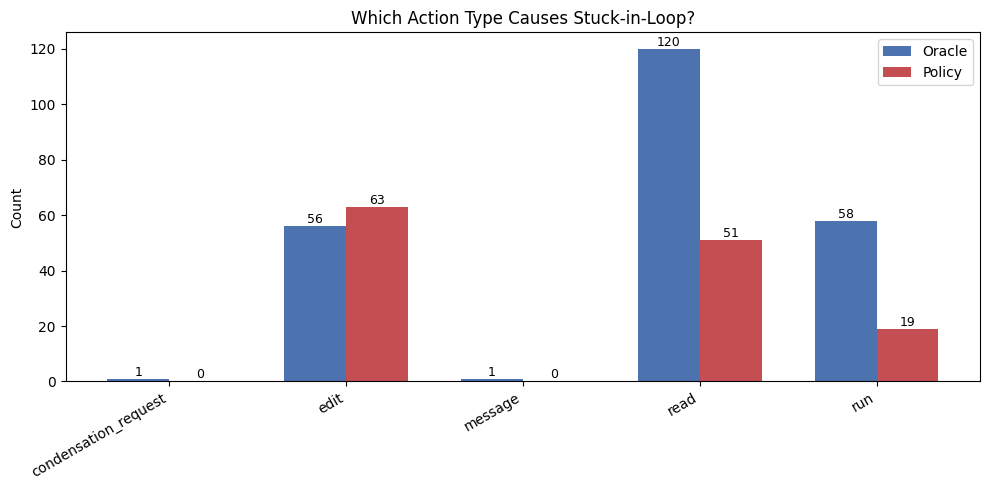

In [47]:
# What action type gets stuck?
def count_loop_action_types(patterns, label):
    action_counts = Counter(p["action_type"] for p in patterns.values())
    print(f"\n{label} — Stuck loop action types:")
    for act, cnt in action_counts.most_common():
        print(f"  {act:<20} {cnt:>5} ({100*cnt/len(patterns):.1f}%)")
    return action_counts

oracle_loop_actions = count_loop_action_types(oracle_patterns, "Oracle")
policy_loop_actions = count_loop_action_types(policy_patterns, "Policy")

# Grouped bar chart
all_act_types = sorted(set(oracle_loop_actions.keys()) | set(policy_loop_actions.keys()))
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(all_act_types))
width = 0.35
o_vals = [oracle_loop_actions.get(t, 0) for t in all_act_types]
p_vals = [policy_loop_actions.get(t, 0) for t in all_act_types]
bars1 = ax.bar(x - width/2, o_vals, width, label="Oracle", color="#4C72B0")
bars2 = ax.bar(x + width/2, p_vals, width, label="Policy", color="#C44E52")
ax.bar_label(bars1, fontsize=9)
ax.bar_label(bars2, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(all_act_types, rotation=30, ha="right")
ax.set_ylabel("Count")
ax.set_title("Which Action Type Causes Stuck-in-Loop?")
ax.legend()
plt.tight_layout()
plt.show()

In [48]:
# Categorize the repeating command/action into higher-level patterns
def categorize_loop(pat):
    """Classify the stuck loop into a human-readable category."""
    act = pat["action_type"]
    cmd = pat["command"].strip()
    path = pat["path"]
    
    if act == "read":
        return "Repeated file read"
    elif act == "edit":
        sub = pat["fingerprint"].split(":")[1] if ":" in pat["fingerprint"] else ""
        if sub in ("str_replace", "replace"):
            return "Repeated str_replace (same edit)"
        elif sub == "insert":
            return "Repeated insert"
        elif sub == "create":
            return "Repeated file create"
        elif sub == "view":
            return "Repeated file view"
        elif sub == "undo_edit":
            return "Repeated undo_edit"
        else:
            return f"Repeated edit ({sub})"
    elif act == "run":
        cmd_lower = cmd.lower()
        if "test" in cmd_lower or "pytest" in cmd_lower or "python -m pytest" in cmd_lower:
            return "Repeated test execution"
        elif "git" in cmd_lower:
            return "Repeated git command"
        elif "cat " in cmd_lower or "head " in cmd_lower or "tail " in cmd_lower:
            return "Repeated file inspection (cat/head/tail)"
        elif "find " in cmd_lower or "grep " in cmd_lower or "ls " in cmd_lower:
            return "Repeated search/find"
        elif "pip " in cmd_lower or "install" in cmd_lower:
            return "Repeated install command"
        elif "cd " in cmd_lower:
            return "Repeated cd + command"
        elif "python" in cmd_lower:
            return "Repeated python script execution"
        else:
            return "Repeated shell command (other)"
    elif act == "message":
        return "Repeated message action"
    elif act == "finish":
        return "Repeated finish action"
    else:
        return f"Repeated {act}"

def pattern_breakdown(patterns, label):
    categories = Counter(categorize_loop(p) for p in patterns.values())
    print(f"\n{label} — Loop Pattern Categories:")
    for cat, cnt in categories.most_common():
        print(f"  {cat:<40} {cnt:>5} ({100*cnt/len(patterns):.1f}%)")
    return categories

oracle_cats = pattern_breakdown(oracle_patterns, "Oracle")
policy_cats = pattern_breakdown(policy_patterns, "Policy")


Oracle — Loop Pattern Categories:
  Repeated file read                         120 (50.8%)
  Repeated str_replace (same edit)            56 (23.7%)
  Repeated cd + command                       38 (16.1%)
  Repeated test execution                     16 (6.8%)
  Repeated search/find                         4 (1.7%)
  Repeated condensation_request                1 (0.4%)
  Repeated message action                      1 (0.4%)

Policy — Loop Pattern Categories:
  Repeated str_replace (same edit)            63 (47.4%)
  Repeated file read                          51 (38.3%)
  Repeated test execution                     12 (9.0%)
  Repeated cd + command                        5 (3.8%)
  Repeated git command                         1 (0.8%)
  Repeated search/find                         1 (0.8%)


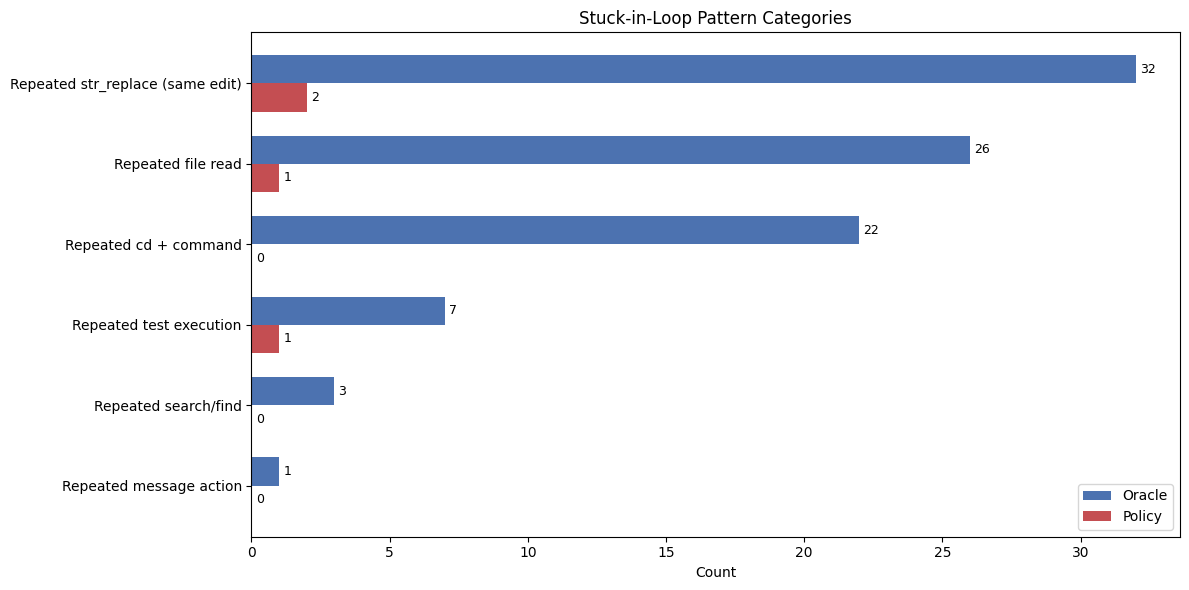

In [28]:
# Visualization: pattern categories comparison
all_cats = sorted(set(oracle_cats.keys()) | set(policy_cats.keys()), 
                  key=lambda c: -(oracle_cats.get(c, 0) + policy_cats.get(c, 0)))

fig, ax = plt.subplots(figsize=(12, 6))
y = np.arange(len(all_cats))
height = 0.35
o_vals = [oracle_cats.get(c, 0) for c in all_cats]
p_vals = [policy_cats.get(c, 0) for c in all_cats]
bars1 = ax.barh(y - height/2, o_vals, height, label="Oracle", color="#4C72B0")
bars2 = ax.barh(y + height/2, p_vals, height, label="Policy", color="#C44E52")
ax.bar_label(bars1, fontsize=9, padding=3)
ax.bar_label(bars2, fontsize=9, padding=3)
ax.set_yticks(y)
ax.set_yticklabels(all_cats)
ax.set_xlabel("Count")
ax.set_title("Stuck-in-Loop Pattern Categories")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [29]:
# Streak length by pattern category
def streak_by_category(patterns):
    cat_streaks = defaultdict(list)
    for p in patterns.values():
        cat = categorize_loop(p)
        cat_streaks[cat].append(p["streak_length"])
    return cat_streaks

oracle_streaks = streak_by_category(oracle_patterns)
policy_streaks = streak_by_category(policy_patterns)

print(f"{'Category':<40} {'Run':>6} {'Count':>6} {'Mean Streak':>12} {'Max Streak':>11}")
print("-" * 78)
for cat in all_cats:
    for label, streaks in [("Oracle", oracle_streaks), ("Policy", policy_streaks)]:
        s = streaks.get(cat, [])
        if s:
            print(f"{cat:<40} {label:>6} {len(s):>6} {np.mean(s):>11.1f} {max(s):>11}")
    print()

Category                                    Run  Count  Mean Streak  Max Streak
------------------------------------------------------------------------------
Repeated str_replace (same edit)         Oracle     32         9.6          31
Repeated str_replace (same edit)         Policy      2         6.5           8

Repeated file read                       Oracle     26        14.2          40
Repeated file read                       Policy      1         5.0           5

Repeated cd + command                    Oracle     22        16.1          73

Repeated test execution                  Oracle      7        16.7          38
Repeated test execution                  Policy      1        32.0          32

Repeated search/find                     Oracle      3         8.3          14

Repeated message action                  Oracle      1         6.0           6



In [49]:
# Show concrete examples of top loop patterns
def show_loop_examples(patterns, label, n=5):
    print(f"\n{'='*100}")
    print(f"{label} — Top {n} Stuck Loop Examples (longest streaks)")
    print(f"{'='*100}")
    sorted_pats = sorted(patterns.items(), key=lambda x: -x[1]["streak_length"])
    for iid, pat in sorted_pats[:n]:
        print(f"\n  Instance: {iid}")
        print(f"  Category: {categorize_loop(pat)}")
        print(f"  Action:   {pat['action_type']}")
        print(f"  Streak:   {pat['streak_length']} repeats (starts at step {pat['start_step']}/{pat['total_steps']})")
        if pat['path']:
            print(f"  Target:   {pat['path']}")
        if pat['command']:
            cmd_display = pat['command'].strip().replace('\n', ' ')[:120]
            print(f"  Command:  {cmd_display}")

show_loop_examples(oracle_patterns, "Oracle")
show_loop_examples(policy_patterns, "Policy")


Oracle — Top 5 Stuck Loop Examples (longest streaks)

  Instance: sphinx-doc__sphinx-9367
  Category: Repeated str_replace (same edit)
  Action:   edit
  Streak:   78 repeats (starts at step 23/101)
  Target:   /workspace/sphinx-doc__sphinx__4.1/sphinx/pycode/ast.py
  Command:  str_replace

  Instance: sympy__sympy-24661
  Category: Repeated file read
  Action:   read
  Streak:   78 repeats (starts at step 23/101)
  Target:   /workspace/sympy__sympy__1.12/sympy/core/relational.py

  Instance: sympy__sympy-22914
  Category: Repeated file read
  Action:   read
  Streak:   75 repeats (starts at step 26/101)
  Target:   /workspace/sympy__sympy__1.10/sympy/printing/pycode.py

  Instance: matplotlib__matplotlib-24026
  Category: Repeated file read
  Action:   read
  Streak:   74 repeats (starts at step 27/101)
  Target:   /workspace/matplotlib__matplotlib__3.6/lib/matplotlib/rcsetup.py

  Instance: django__django-15499
  Category: Repeated file read
  Action:   read
  Streak:   73 repeats (

## 8. Error Breakdown

In [17]:
def error_breakdown(stats, label):
    errors = Counter()
    for s in stats.values():
        err = s["error"]
        if err:
            # Normalize error to just the error class name
            err_type = err.split(":")[0].strip() if ":" in err else err[:60]
            errors[err_type] += 1
        else:
            errors["(no error)"] += 1
    print(f"\n{label} Error Breakdown:")
    for err_type, count in errors.most_common():
        print(f"  {count:>5}  {err_type}")

error_breakdown(oracle_stats, "Oracle")
error_breakdown(policy_stats, "Policy")


Oracle Error Breakdown:
    194  (no error)
    187  RuntimeError
    110  AgentStuckInLoopError
      5  RequestHTTPError

Policy Error Breakdown:
    267  (no error)
    222  RuntimeError
      8  AgentStuckInLoopError


## 9. Summary Table

In [18]:
def compute_summary(stats, resolved_set, report, label):
    steps = [s["step_count"] for s in stats.values()]
    misuse = [s["tool_misuse_rate"] for s in stats.values()]
    stuck = sum(1 for s in stats.values() if s["stuck_in_loop"])
    n = len(stats)
    return {
        "Run": label,
        "Total": report.get("total_instances", n),
        "Submitted": report.get("submitted_instances", n),
        "Resolved": len(resolved_set),
        "Resolve %": f"{100*len(resolved_set)/report.get('total_instances', n):.1f}%",
        "Mean Steps": f"{np.mean(steps):.1f}",
        "Median Steps": f"{np.median(steps):.0f}",
        "Mean Misuse %": f"{100*np.mean(misuse):.1f}%",
        "Stuck Loop %": f"{100*stuck/n:.1f}%",
    }

rows = [
    compute_summary(oracle_stats, oracle_resolved, oracle_report, "Oracle"),
    compute_summary(policy_stats, policy_resolved, policy_report, "Policy"),
]

# Print as table
keys = list(rows[0].keys())
col_widths = [max(len(str(r[k])) for r in rows + [{k: k for k in keys}]) for k in keys]
header = " | ".join(k.ljust(w) for k, w in zip(keys, col_widths))
print(header)
print("-" * len(header))
for r in rows:
    print(" | ".join(str(r[k]).ljust(w) for k, w in zip(keys, col_widths)))

Run    | Total | Submitted | Resolved | Resolve % | Mean Steps | Median Steps | Mean Misuse % | Stuck Loop %
------------------------------------------------------------------------------------------------------------
Oracle | 496   | 463       | 111      | 22.4%     | 82.0       | 88           | 17.5%         | 22.2%       
Policy | 500   | 497       | 213      | 42.6%     | 86.1       | 94           | 16.4%         | 1.6%        
